In [1]:
import os
import sys

os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

PROJECT_ROOT = "/Users/saratramontana/Documents/GitHub/test_segmentation_model"
os.chdir(PROJECT_ROOT)

sys.path.append(PROJECT_ROOT)
sys.path.append(os.path.join(PROJECT_ROOT, "external", "ACSNet"))
sys.path.append(os.path.join(PROJECT_ROOT, "external", "OvaMTA"))

import torch
import wandb
import lightning as L
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import cv2
import io
from PIL import Image

from lightning.pytorch.loggers import WandbLogger
from lightning.pytorch.callbacks import ModelCheckpoint
from torchvision import transforms

from new_data.data_loader import train_df, val_df
from training.factories import build_dataloaders, build_lightning_module

from lib.OvaMTA_seg import TransRaUNet_CLF_xiaorong as OvaSegModel
from lib.OvaMTA_diag import TransRaUNet_CLF_xiaorong as OvaDiagModel

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

/Users/saratramontana/anaconda3/envs/test-seg/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/saratramontana/anaconda3/envs/test-seg/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/Users/saratramontana/anaconda3/envs/test-seg/lib/python3.12/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/Users/saratramontana/Documents/GitHub/test_segmentation_model/external/OvaMTA/lib/pvtv2.py:387: UserWarni

In [2]:
MODEL_NAME = "baseline"
# MODEL_NAME = "acsnet"
# MODEL_NAME = "ovamta"

CONFIG = {
    "batch_size": 8,
    "max_epochs": 10,
    "wandb_project": "single_model_training",

    "lr": 1e-3,

    "lr_ovamta_seg": 1e-4,
    "lr_ovamta_diag": 1e-4,

    "acsnet_seg_loss_mode": "ce_lossnet",
    "acsnet_gamma": 0.2,
}

In [3]:
def train_one_model(model_name, lr):
    train_loader, val_loader = build_dataloaders(
        model_name=model_name,
        train_df=train_df,
        val_df=val_df,
        batch_size=CONFIG["batch_size"],
    )

    model = build_lightning_module(
        model_name=model_name,
        lr=lr,
        train_df=train_df,
        seg_loss_mode=CONFIG["acsnet_seg_loss_mode"],
        gamma=CONFIG["acsnet_gamma"],
    )

    wandb_logger = WandbLogger(
        project=CONFIG["wandb_project"],
        name=f"{model_name}_lr_{lr}",
        log_model=False,
    )

    checkpoint_callback = ModelCheckpoint(
        monitor="val_loss",
        mode="min",
        save_top_k=1,
    )

    trainer = L.Trainer(
        max_epochs=CONFIG["max_epochs"],
        log_every_n_steps=1,
        logger=wandb_logger,
        callbacks=[checkpoint_callback],
    )

    trainer.fit(
        model,
        train_dataloaders=train_loader,
        val_dataloaders=val_loader,
    )

    metrics = trainer.callback_metrics

    result = {
        "model": model_name,
        "lr": lr,
        "best_ckpt_path": checkpoint_callback.best_model_path,
    }

    metric_names = [
        "val_loss",
        "val_seg_loss",
        "val_cls_loss",
        "val_cls_acc",
        "val_seg_dice",
        "val_seg_iou",
        "val_cls_f1",
        "val_cls_precision",
        "val_cls_recall",
        "val_cls_auc",
    ]

    for name in metric_names:
        value = metrics.get(name)
        result[name] = None if value is None else float(value.detach().cpu())

    wandb.finish()

    return result

In [4]:
def show_segcls_result(image_tensor, true_mask, pred_mask, true_label, pred_label):
    image = image_tensor.detach().cpu()

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    image = image * std + mean
    image = image.clamp(0, 1)
    image_np = image.permute(1, 2, 0).numpy()

    true_mask_np = true_mask.detach().cpu().numpy()
    pred_mask_np = pred_mask.detach().cpu().numpy()

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(image_np)
    plt.title("Original image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(true_mask_np, cmap="gray")
    plt.title("True mask")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(pred_mask_np, cmap="gray")
    plt.title(f"Pred mask\npred={pred_label} | true={true_label}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [5]:
def show_segcls_model_results(model_name, ckpt_path, sample_idx=0):
    _, val_loader = build_dataloaders(
        model_name=model_name,
        train_df=train_df,
        val_df=val_df,
        batch_size=1,
    )

    model = build_lightning_module(
        model_name=model_name,
        lr=CONFIG["lr"],
        train_df=train_df,
        seg_loss_mode=CONFIG["acsnet_seg_loss_mode"],
        gamma=CONFIG["acsnet_gamma"],
    )

    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt["state_dict"])
    model.to(device)
    model.eval()

    dataset = val_loader.dataset
    image, true_mask, true_label = dataset[sample_idx]

    x = image.unsqueeze(0).to(device)

    with torch.no_grad():
        if model_name == "baseline":
            seg_logits, cls_logits = model(x)
        elif model_name == "acsnet":
            cls_logits, seg_logits = model(x)
        else:
            raise ValueError(model_name)

    pred_mask = torch.argmax(seg_logits, dim=1)[0].cpu()
    pred_label = torch.argmax(cls_logits, dim=1)[0].cpu().item()

    show_segcls_result(
        image_tensor=image,
        true_mask=true_mask,
        pred_mask=pred_mask,
        true_label=int(true_label),
        pred_label=pred_label,
    )

In [6]:
def load_lightning_checkpoint_into_ovamta(model, ckpt_path, device):
    ckpt = torch.load(ckpt_path, map_location=device)
    state_dict = ckpt["state_dict"]

    new_state_dict = {}

    for k, v in state_dict.items():
        if k.startswith("model."):
            new_key = k.replace("model.", "", 1) #perchè Lightning salva i pesi così:"model.encoder.conv1.weight", mentre il modello puro si aspetta: "encoder.conv1.weight" quindi devo rimuovere quel model.

            new_state_dict[new_key] = v

    model.load_state_dict(new_state_dict)
    model.to(device)
    model.eval()

    return model

In [7]:
TR_SIZE = 352

img_transform = transforms.Compose([
    transforms.Resize((TR_SIZE, TR_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

In [8]:
def predict_stage1_roi(image, model_seg, device, margin_352=10, ovary_threshold=0.1):
    orig_w, orig_h = image.size

    x = img_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        out5, out4, out3, out2, cls_out_seg, features = model_seg(x)
        res = out5 + out4 + out3 + out2

        mask_pred_352 = (res[0, 0] > 0).cpu().numpy().astype(np.uint8)

        stage1_raw = cls_out_seg[0].detach().cpu().numpy()
        p_healthy = float(stage1_raw[0])
        p_benign_mass = float(stage1_raw[1])
        p_malignant_mass = float(stage1_raw[2])

    contours, _ = cv2.findContours(
        mask_pred_352,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_NONE
    )

    if len(contours) == 0:
        bbox = (0, 0, orig_w, orig_h)
        has_roi = False
    else:
        c = max(contours, key=cv2.contourArea)
        x_352, y_352, w_352, h_352 = cv2.boundingRect(c)

        x1_352 = max(0, x_352 - margin_352)
        y1_352 = max(0, y_352 - margin_352)
        x2_352 = min(TR_SIZE, x_352 + w_352 + margin_352)
        y2_352 = min(TR_SIZE, y_352 + h_352 + margin_352)

        scale_x = orig_w / TR_SIZE
        scale_y = orig_h / TR_SIZE

        x_min = int(x1_352 * scale_x)
        y_min = int(y1_352 * scale_y)
        x_max = int(x2_352 * scale_x)
        y_max = int(y2_352 * scale_y)

        x_min = max(0, x_min)
        y_min = max(0, y_min)
        x_max = min(orig_w, x_max)
        y_max = min(orig_h, y_max)

        if x_max <= x_min or y_max <= y_min:
            bbox = (0, 0, orig_w, orig_h)
            has_roi = False
        else:
            bbox = (x_min, y_min, x_max, y_max)
            has_roi = True

    is_ovary = p_healthy >= ovary_threshold

    return {
        "mask_pred_352": mask_pred_352,
        "bbox": bbox,
        "has_roi": has_roi,
        "is_ovary": is_ovary,
        "is_mass": not is_ovary,
        "stage1_raw": stage1_raw,
        "p_healthy": p_healthy,
        "p_benign_mass": p_benign_mass,
        "p_malignant_mass": p_malignant_mass,
    }

In [9]:
def predict_stage2_diagnosis(image, bbox, model_diag, device, benign_threshold=0.65):
    x_min, y_min, x_max, y_max = bbox

    if x_max <= x_min or y_max <= y_min:
        x_min, y_min, x_max, y_max = 0, 0, image.size[0], image.size[1]

    patch = image.crop((x_min, y_min, x_max, y_max))
    x_patch = img_transform(patch).unsqueeze(0).to(device)

    with torch.no_grad():
        out5, out4, out3, out2, cls_out_diag, features = model_diag(x_patch)

    raw = cls_out_diag[0].detach().cpu().numpy()

    p_benign_raw = float(raw[0])
    p_malignant_raw = float(raw[1])

    if p_benign_raw > benign_threshold:
        pred_label = 0
        pred_class = "benign"
    else:
        pred_label = 1
        pred_class = "malignant"

    probs = torch.softmax(cls_out_diag, dim=1)[0].detach().cpu().numpy()

    return {
        "patch": patch,
        "stage2_raw": raw,
        "stage2_softmax": probs,
        "p_benign_raw": p_benign_raw,
        "p_malignant_raw": p_malignant_raw,
        "prob_benign_softmax": float(probs[0]),
        "prob_malignant_softmax": float(probs[1]),
        "pred_label": pred_label,
        "pred_class": pred_class
    }

In [10]:
def ovamta_inference_one_row(row, model_seg, model_diag, device):
    image = Image.open(io.BytesIO(row["image"])).convert("RGB")

    stage1 = predict_stage1_roi(
        image=image,
        model_seg=model_seg,
        device=device,
        margin_352=10,
        ovary_threshold=0.1
    )

    true_label = int(row["risk_class"])

    if stage1["is_ovary"]:
        return {
            "image": image,
            "mask_pred_352": stage1["mask_pred_352"],
            "bbox": stage1["bbox"],
            "has_roi": stage1["has_roi"],
            "stage1_raw": stage1["stage1_raw"],
            "p_healthy": stage1["p_healthy"],
            "p_benign_mass": stage1["p_benign_mass"],
            "p_malignant_mass": stage1["p_malignant_mass"],

            "patch": None,
            "stage2_raw": None,
            "stage2_softmax": None,
            "p_benign_raw": None,
            "p_malignant_raw": None,
            "prob_benign_softmax": None,
            "prob_malignant_softmax": None,

            "pred_label": 2,
            "pred_class": "healthy_ovary",

            "true_label": true_label,
            "true_class": (
                "healthy_ovary" if true_label == 2
                else "malignant" if true_label == 1
                else "benign"
            )
        }

    stage2 = predict_stage2_diagnosis(
        image=image,
        bbox=stage1["bbox"],
        model_diag=model_diag,
        device=device,
        benign_threshold=0.65
    )

    return {
        "image": image,
        "mask_pred_352": stage1["mask_pred_352"],
        "bbox": stage1["bbox"],
        "has_roi": stage1["has_roi"],
        "stage1_raw": stage1["stage1_raw"],
        "p_healthy": stage1["p_healthy"],
        "p_benign_mass": stage1["p_benign_mass"],
        "p_malignant_mass": stage1["p_malignant_mass"],

        "patch": stage2["patch"],
        "stage2_raw": stage2["stage2_raw"],
        "stage2_softmax": stage2["stage2_softmax"],
        "p_benign_raw": stage2["p_benign_raw"],
        "p_malignant_raw": stage2["p_malignant_raw"],
        "prob_benign_softmax": stage2["prob_benign_softmax"],
        "prob_malignant_softmax": stage2["prob_malignant_softmax"],
        "pred_label": stage2["pred_label"],
        "pred_class": stage2["pred_class"],

        "true_label": true_label,
        "true_class": (
            "healthy_ovary" if true_label == 2
            else "malignant" if true_label == 1
            else "benign"
        )
    }

In [11]:
def show_inference_result(result):
    image_np = np.array(result["image"])
    x_min, y_min, x_max, y_max = result["bbox"]

    image_box = image_np.copy()

    cv2.rectangle(
        image_box,
        (x_min, y_min),
        (x_max, y_max),
        color=(255, 255, 255),
        thickness=3
    )

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(image_box)
    plt.title("Original + bbox")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(result["mask_pred_352"], cmap="gray")
    plt.title("Stage 1 predicted mask")
    plt.axis("off")

    plt.subplot(1, 3, 3)

    if result["patch"] is not None:
        plt.imshow(result["patch"])
        plt.title(
            f"Patch\npred={result['pred_class']} | true={result['true_class']}"
        )
    else:
        plt.text(
            0.5,
            0.5,
            f"No patch\npred={result['pred_class']} | true={result['true_class']}",
            ha="center",
            va="center",
            fontsize=12,
        )

    plt.axis("off")
    plt.tight_layout()
    plt.show()


def show_ovamta_results(model_seg, model_diag, device, sample_idx=0):
    all_results = []

    for idx in range(len(val_df)):
        result = ovamta_inference_one_row(
            row=val_df.iloc[idx],
            model_seg=model_seg,
            model_diag=model_diag,
            device=device,
        )

        all_results.append({
            "idx": idx,
            "true_label": result["true_label"],
            "true_class": result["true_class"],
            "pred_label": result["pred_label"],
            "pred_class": result["pred_class"],
            "has_roi": result["has_roi"],
            "bbox": result["bbox"],
            "p_healthy": result["p_healthy"],
            "p_benign_mass": result["p_benign_mass"],
            "p_malignant_mass": result["p_malignant_mass"],
            "p_benign_raw": result["p_benign_raw"],
            "p_malignant_raw": result["p_malignant_raw"],
            "prob_benign_softmax": result["prob_benign_softmax"],
            "prob_malignant_softmax": result["prob_malignant_softmax"],
        })

    results_df = pd.DataFrame(all_results)

    display(results_df.head())

    accuracy = (results_df["true_label"] == results_df["pred_label"]).mean()
    print("Validation accuracy:", accuracy)

    display(pd.crosstab(
        results_df["true_class"],
        results_df["pred_class"],
        rownames=["True"],
        colnames=["Pred"]
    ))

    visual_result = ovamta_inference_one_row(
        row=val_df.iloc[sample_idx],
        model_seg=model_seg,
        model_diag=model_diag,
        device=device,
    )

    show_inference_result(visual_result)

    return results_df

In [12]:
def show_model_results(
    model_name,
    ckpt_path=None,
    seg_ckpt_path=None,
    diag_ckpt_path=None,
    sample_idx=0,
):
    if model_name in ["baseline", "acsnet"]:
        return show_segcls_model_results(
            model_name=model_name,
            ckpt_path=ckpt_path,
            sample_idx=sample_idx,
        )

    elif model_name == "ovamta":
        model_seg = OvaSegModel(training=False)
        model_diag = OvaDiagModel(training=False)

        model_seg = load_lightning_checkpoint_into_ovamta(
            model=model_seg,
            ckpt_path=seg_ckpt_path,
            device=device,
        )

        model_diag = load_lightning_checkpoint_into_ovamta(
            model=model_diag,
            ckpt_path=diag_ckpt_path,
            device=device,
        )

        return show_ovamta_results(
            model_seg=model_seg,
            model_diag=model_diag,
            device=device,
            sample_idx=sample_idx,
        )

    else:
        raise ValueError(f"Unknown model_name: {model_name}")

In [13]:
def run_training_for_model(model_name):
    if model_name in ["baseline", "acsnet"]:
        result = train_one_model(
            model_name=model_name,
            lr=CONFIG["lr"],
        )

        results_df = pd.DataFrame([result])
        display(results_df)

        show_model_results(
            model_name=model_name,
            ckpt_path=result["best_ckpt_path"],
            sample_idx=0,
        )

        os.makedirs("results", exist_ok=True)
        results_df.to_csv(f"results/{model_name}_results.csv", index=False)

        return results_df

    elif model_name == "ovamta":
        seg_result = train_one_model(
            model_name="ovamta_seg",
            lr=CONFIG["lr_ovamta_seg"],
        )

        diag_result = train_one_model(
            model_name="ovamta_diag",
            lr=CONFIG["lr_ovamta_diag"],
        )

        results_df = pd.DataFrame([seg_result, diag_result])
        display(results_df)

        ovamta_predictions_df = show_model_results(
            model_name="ovamta",
            seg_ckpt_path=seg_result["best_ckpt_path"],
            diag_ckpt_path=diag_result["best_ckpt_path"],
            sample_idx=0,
        )

        os.makedirs("results", exist_ok=True)
        results_df.to_csv("results/ovamta_results.csv", index=False)
        ovamta_predictions_df.to_csv("results/ovamta_predictions_val.csv", index=False)

        return results_df

    else:
        raise ValueError(f"Unknown model_name: {model_name}")

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/saratramontana/.netrc.
wandb: Currently logged in as: sara-tramontana02 (sara-tramontana02-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                ┃ Type                   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ model               │ Unet                   │ 24.4 M │ train │     0 │
│ 1  │ seg_criterion       │ CrossEntropyLoss       │      0 │ train │     0 │
│ 2  │ cls_criterion       │ CrossEntropyLoss       │      0 │ train │     0 │
│ 3  │ train_cls_f1        │ BinaryF1Score          │      0 │ train │     0 │
│ 4  │ train_cls_precision │ BinaryPrecision        │      0 │ train │     0 │
│ 5  │ train_cls_recall    │ BinaryRecall           │      0 │ train │     0 │
│ 6  │ train_cls_auc       │ BinaryAUROC            │      0 │ train │     0 │
│ 7  │ val_cls_f1          │ BinaryF1Score          │      0 │ train │     0 │
│ 8  │ val_cls_precision   │ BinaryPrecision        │      0 │ train │     0 │
│ 9  │ val_cls_recall      │ BinaryRecall           │      0 │ train │     0 │
│ 10 │ val_cls_auc         │ BinaryAUROC            │      0 │ train │     0 │
│ 11 │ train_seg_dice      │ MulticlassF1Score      │      0 │ train │     0 │
│ 12 │ train_seg_iou       │ MulticlassJaccardIndex │      0 │ train │     0 │
│ 13 │ val_seg_dice        │ MulticlassF1Score      │      0 │ train │     0 │
│ 14 │ val_seg_iou         │ MulticlassJaccardIndex │      0 │ train │     0 │
└────┴─────────────────────┴────────────────────────┴────────┴───────┴───────┘

Trainable params: 24.4 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 24.4 M                                                                                               
Total estimated model params size (MB): 97                                                                         
Modules in train mode: 209                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/Users/saratramontana/anaconda3/envs/test-seg/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Users/saratramontana/anaconda3/envs/test-seg/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:2
1: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

...

/Users/saratramontana/anaconda3/envs/test-seg/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: 
UserWarning: No negative samples in targets, false positive value should be meaningless. Returning zero tensor in 
false positive score
  warnings.warn(*args, **kwargs)

/Users/saratramontana/anaconda3/envs/test-seg/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/dat
a_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider 
increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

`Trainer.fit` stopped: `max_epochs=10` reached.


epoch,▁▁▁▁▂▂▃▃▃▃▃▃▃▃▄▅▅▅▅▅▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇█████
global_step,▁▂▂▃▄▅▅▆▇▇█
train_cls_acc_epoch,▁▆▆▆▇▅▇█▆▇
train_cls_acc_step,███▁██▁█████▁██▁▁█▁█▁████▁██████████▁███
train_cls_auc,▆▇▇██▁███▁
train_cls_f1,▁▆▇▇▇▅▇█▆▇
train_cls_loss_epoch,█▃▂▁▁▃▁▁▂▁
train_cls_loss_step,▁▁▁▂█▁▂▃▁▁▁▁▂▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▂▂▁▁▁▁
train_cls_precision,▁█▇▅▇▇█▇▅█
train_cls_recall,▁▅▆▇▇▄▆█▆▆
+17,...


,model,lr,best_ckpt_path,val_loss,val_seg_loss,val_cls_loss,val_cls_acc,val_seg_dice,val_seg_iou,val_cls_f1,val_cls_precision,val_cls_recall,val_cls_auc
0,baseline,0.001,./single_model_training/6vl0bkyh/checkpoints/e...,1.969277,0.559513,1.409764,0.691176,0.638469,0.533461,0.8,0.976744,0.677419,0.766129


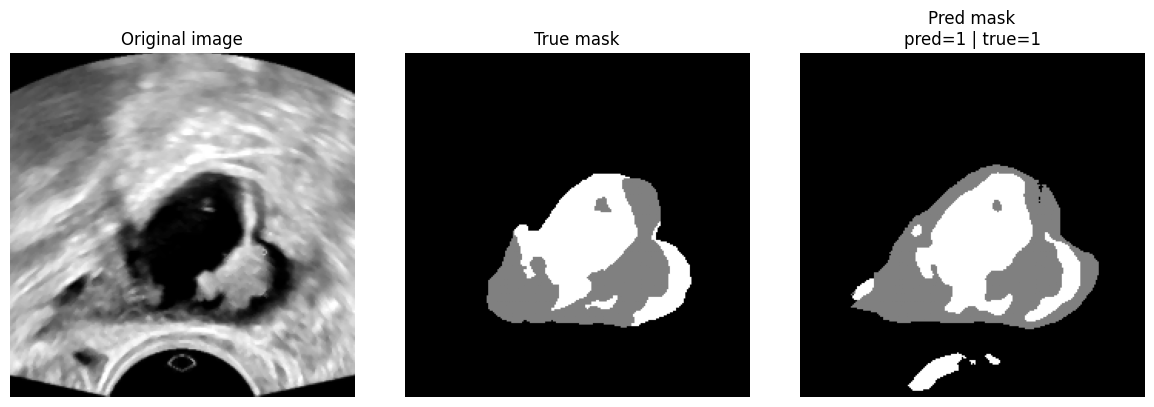

In [14]:
results_df = run_training_for_model(MODEL_NAME)